In [1]:

import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import logging
import mira
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings('ignore')

/home/haiyi/anaconda3/envs/mira/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
## model setup
atac_model = mira.topics.AccessibilityTopicModel(counts_layer='counts', dataset_loader_workers = 3)

rna_model = mira.topics.ExpressionTopicModel(
    endogenous_key='endog',
    exogenous_key='endog',
    counts_layer='counts',
    seed = 0,
    hidden=64, # to make the tutorial faster. In practice, use the default of 128!
)          

rna_model = mira.topics.ExpressionTopicModel.load('/mnt/data0/HierachicalCausal_Omics/MIRA/rna_topic_model_multivelo.pth')
atac_model = mira.topics.AccessibilityTopicModel.load('/mnt/data0/HierachicalCausal_Omics/MIRA/atac_topic_model_multivelo.pth')

INFO:mira.topic_model.base:Moving model to CPU for inference.
INFO:mira.topic_model.base:Moving model to device: cpu
INFO:mira.topic_model.base:Moving model to CPU for inference.
INFO:mira.topic_model.base:Moving model to device: cpu


In [19]:
## loading the data
# rna_data = anndata.read_h5ad("data/datasets/mouse_hair_rna_interim.h5ad")
# atac_data =  anndata.read_h5ad("data/datasets/mouse_hair_atac_interim.h5ad")

rna_data = sc.read_h5ad("/mnt/data0/dataset/halo/mouse_brain_rna_mira.h5ad")
atac_data = sc.read_h5ad("/mnt/data0/dataset/halo/mouse_brain_atac_mira.h5ad")

In [22]:
rna_model = mira.topics.ExpressionTopicModel.load('/mnt/data0/HierachicalCausal_Omics/MIRA/rna_topic_model.pth')
atac_model = mira.topics.AccessibilityTopicModel.load('/mnt/data0/HierachicalCausal_Omics/MIRA/atac_topic_model.pth')

INFO:mira.topic_model.base:Moving model to CPU for inference.
INFO:mira.topic_model.base:Moving model to device: cpu
INFO:mira.topic_model.base:Moving model to CPU for inference.
INFO:mira.topic_model.base:Moving model to device: cpu


In [28]:
mira.tl.get_distance_to_TSS(atac_data,
                            tss_data='/mnt/data0/HierachicalCausal_Omics/mira-datasets/mm10_tss_data.bed12',
                            genome_file='/mnt/data0/HierachicalCausal_Omics/mira-datasets/mm10.chrom.sizes')

INFO:mira.tools.connect_genes_peaks:Finding peak intersections with promoters ...
INFO:mira.tools.connect_genes_peaks:Calculating distances between peaks and TSS ...
INFO:mira.tools.connect_genes_peaks:Masking other genes' promoters ...
INFO:mira.adata_interface.rp_model:Added key to var: distance_to_TSS
INFO:mira.adata_interface.rp_model:Added key to uns: distance_to_TSS_genes


In [82]:
rna_data.var.index = rna_data.var.index.str.upper()
rp_args = dict(expr_adata = rna_data, atac_adata= atac_data)
rp_genes = list(rna_model.features[rna_model.highly_variable])[:800]
rp_genes = [str(e).upper() for e in rp_genes]
rp_genes = [x for x in rp_genes if x not in [" GM5089-1", "PAKAP-1","GM5089-1"]]


In [83]:
litemodel = mira.rp.LITE_Model(expr_model = rna_model,
                              accessibility_model=atac_model,
                              counts_layer='counts',
                              genes = rp_genes)

In [84]:
litemodel.fit(**rp_args, n_workers=4,
              callback = mira.rp.SaveCallback("/mnt/data0/HierachicalCausal_Omics/rpmodels/mb/"))

Fitting models: 100%|██████████| 799/799 [04:43<00:00,  2.82it/s]


In [6]:
litemodel.load("/mnt/data0/HierachicalCausal_Omics/rpmodels/mb/")

In [48]:
rna_data.var.index = rna_data.var.index.str.upper()
rna_data.obs["latent_time_cat"] = pd.cut(rna_data.obs['latent_time'], 20, labels=[str(i) for i in range(20)])
rna_data.obs["latent_time_2"] = pd.cut(rna_data.obs['latent_time'], 50, labels=[str(i) for i in range(50)])
rna_data.obs["latent_time_10"] = pd.cut(rna_data.obs['latent_time'], 10, labels=[str(i) for i in range(10)])
rna_data.obs["latent_time_3"] = pd.cut(rna_data.obs['latent_time'], 5, labels=[str(i) for i in range(5)])
rna_data.obs["latent_time_8"] = pd.cut(rna_data.obs['latent_time'], 8, labels=[str(i) for i in range(8)])
rna_data.obs["latent_time_6"] = pd.cut(rna_data.obs['latent_time'], 6, labels=[str(i) for i in range(6)])

In [49]:
from gene_peaks import tfidf_norm

norm_X =  tfidf_norm(atac_data, scale_factor=1e4)

In [50]:
atac_data.layers["norm"] = norm_X

In [51]:
genelist = rp_genes
print(len(genelist))

300


In [53]:
celltypes = rna_data.obs.celltype.unique().tolist()
celltypes

['Upper Layer',
 'RG, Astro, OPC',
 'Deeper Layer',
 'Subplate',
 'V-SVZ',
 'IPC',
 'Ependymal cells']

In [54]:
## categorized by cell types
ULrna = rna_data[(rna_data.obs.celltype=="Upper Layer")]
ULatac = atac_data[(atac_data.obs.celltype=="Upper Layer")]


RAOrna = rna_data[(rna_data.obs.celltype=="RG, Astro, OPC")]
RAOatac = atac_data[(atac_data.obs.celltype=="RG, Astro, OPC")]


DLrna = rna_data[(rna_data.obs.celltype=="Deeper Layer")]
DLatac = atac_data[(atac_data.obs.celltype=="Deeper Layer")]


Subplaterna = rna_data[(rna_data.obs.celltype=="Subplate")]
Subplateatac = atac_data[(atac_data.obs.celltype=="Subplate")]


VSVZrna = rna_data[(rna_data.obs.celltype=="V-SVZ")]
VSVZatac = atac_data[(atac_data.obs.celltype=="V-SVZ")]

IPCrna = rna_data[(rna_data.obs.celltype=="IPC")]
IPCatac = atac_data[(atac_data.obs.celltype=="IPC")]


DCrna = rna_data[(rna_data.obs.celltype=="Ependymal cells")]
DCatac = atac_data[(atac_data.obs.celltype=="Ependymal cells")]


In [89]:
decouple_score_UL = []
couple_score_UL = []

decouple_score_RAO = []
couple_score_RAO = []

decouple_score_DL = []
couple_score_DL = []

decouple_score_Subplate = []
couple_score_Subplate= []

decouple_score_VSVZ = []
couple_score_VSVZ = []

decouple_score_IPC = []
couple_score_IPC = []

decouple_score_DC = []
couple_score_DC= []

failed = []

In [86]:
genelist = pd.read_csv("gene_score_mousebrain_500.csv")["gene"].tolist()
print(len(genelist))

478


In [88]:
len(rp_genes)

799

In [87]:
newgenelist  = list(set(rp_genes) - set(genelist))
len(newgenelist)

607

In [90]:
from gene_peaks import gene_level_casual_nonzero

newglist = []
for i in tqdm(range(len(rp_genes))):
    genename = rp_genes[i]
    width= 1e-3
    thresh=0
    time = "latent_time_8"

    try: 
        decouple_score_t, _, _, couple_score_t = gene_level_casual_nonzero(genename,time, litemodel,ULrna, ULatac, norm_X=ULatac.layers["norm"],width=width, thresh=thresh)


        decouple_score_c, _, _, couple_score_c = gene_level_casual_nonzero(genename,time, litemodel,RAOrna,RAOatac, norm_X=RAOatac.layers["norm"],width=width, thresh=thresh)



        decouple_score_i, _, _, couple_score_i = gene_level_casual_nonzero(genename,time, litemodel,DLrna,DLatac, norm_X=DLatac.layers["norm"],width=width, thresh=thresh)



        decouple_score_m, _, _, couple_score_m = gene_level_casual_nonzero(genename,time, litemodel,Subplaterna,Subplateatac, norm_X=Subplateatac.layers["norm"],width=width, thresh=thresh)

        
        decouple_score_v, _, _, couple_score_v = gene_level_casual_nonzero(genename,time, litemodel,VSVZrna,VSVZatac, norm_X=VSVZatac.layers["norm"],width=width, thresh=thresh)


        decouple_score_p, _, _, couple_score_p = gene_level_casual_nonzero(genename,time, litemodel,IPCrna,IPCatac, norm_X=IPCatac.layers["norm"],width=width, thresh=thresh)
      
        

        decouple_score_d, _, _, couple_score_d = gene_level_casual_nonzero(genename,time, litemodel,DCrna,DCatac, norm_X=DCatac.layers["norm"],width=width, thresh=thresh)


        decouple_score_DC.append(decouple_score_d)
        couple_score_DC.append(couple_score_d)           
        
        decouple_score_UL.append(decouple_score_t)
        couple_score_UL.append(couple_score_t)

        decouple_score_RAO.append(decouple_score_c)
        couple_score_RAO.append(couple_score_c)

        decouple_score_DL.append(decouple_score_i)
        couple_score_DL.append(couple_score_i)

        decouple_score_Subplate.append(decouple_score_m)
        couple_score_Subplate.append(couple_score_m)

        decouple_score_VSVZ.append(decouple_score_v)
        couple_score_VSVZ.append(couple_score_v)

        decouple_score_IPC.append(decouple_score_p)
        couple_score_IPC.append(couple_score_p)   

        
        newglist.append(genename)

    except:
        print(genename)
        failed.append(genename)



  4%|▍         | 32/799 [00:34<17:10,  1.34s/it]

GM8251


  8%|▊         | 66/799 [01:10<21:06,  1.73s/it]

EPHA4


 10%|▉         | 76/799 [01:19<10:26,  1.15it/s]

...

 98%|█████████▊| 787/799 [13:49<00:11,  1.07it/s]

TAFA1


 99%|█████████▉| 792/799 [13:55<00:09,  1.32s/it]

CNTN3


100%|██████████| 799/799 [14:00<00:00,  1.05s/it]


In [77]:
print(len(decouple_score_UL), len(couple_score_UL))

192 192


In [91]:
score_df = pd.DataFrame({"gene":newglist, "decouple_UL": decouple_score_UL, "couple_UL":couple_score_UL, 
"decouple_RAO":decouple_score_RAO, "couple_RAO":couple_score_RAO, "decouple_DL":decouple_score_DL, 
"couple_DL":couple_score_DL, "decouple_Subplate":decouple_score_Subplate, "couple_Subplate":couple_score_Subplate, 
"decouple_VSVZ": decouple_score_VSVZ, "couple_VSVZ": couple_score_VSVZ, "decouple_IPC": decouple_score_IPC, 
"couple_IPC":couple_score_IPC, "decouple_DC":decouple_score_DC, "couple_DC": couple_score_DC})
score_df

,gene,decouple_UL,couple_UL,decouple_RAO,couple_RAO,decouple_DL,couple_DL,decouple_Subplate,couple_Subplate,decouple_VSVZ,couple_VSVZ,decouple_IPC,couple_IPC,decouple_DC,couple_DC
0,RP1,NaN,NaN,0.015413,-0.015413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LYPLA1,0.010257,-0.010257,0.007140,-0.007140,-0.005966,0.005966,0.000537,-0.000537,NaN,NaN,NaN,NaN,0.002408,-0.002408
2,RGS20,-0.004014,0.004014,-0.000878,0.000878,-0.003422,0.003422,-0.000827,0.000827,NaN,NaN,NaN,NaN,NaN,NaN
3,ST18,-0.020118,0.020118,0.003690,-0.003690,-0.001180,0.001180,NaN,NaN,NaN,NaN,NaN,NaN,0.007617,-0.007617
4,SNTG1,-0.003941,0.003941,-0.008925,0.008925,-0.001890,0.001890,-0.001794,0.001794,0.040467,-0.040467,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,CNTN4,-0.006032,0.006032,0.019210,-0.019210,-0.003436,0.003436,0.010556,-0.010556,NaN,NaN,-3.261280e-16,3.261280e-16,NaN,NaN
764,ITPR1,-0.005012,0.005012,-0.001247,0.001247,-0.000265,0.000265,-0.004548,0.004548,NaN,NaN,NaN,NaN,0.002703,-0.002703
765,GRM7,-0.002797,0.002797,-0.013074,0.013074,-0.004260,0.004260,-0.005660,0.005660,NaN,NaN,NaN,NaN,0.000283,-0.000283
766,LMCD1,-0.012899,0.012899,-0.007751,0.007751,0.016982,-0.016982,NaN,NaN,NaN,NaN,8.351653e-14,-8.351653e-14,NaN,NaN


In [92]:
score_df.to_csv("gene_score_mousebrain_800.csv")

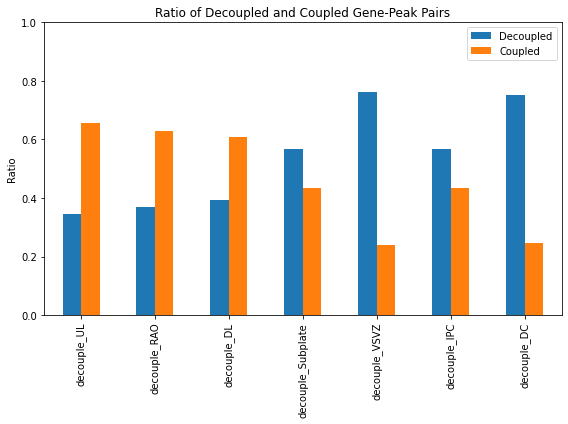

In [93]:
from gene_peaks import plot_ratio


plot_ratio(score_df, ["decouple_UL", "decouple_RAO", "decouple_DL", "decouple_Subplate", "decouple_VSVZ", "decouple_IPC", "decouple_DC"], name="mouse_mouse_celltype800_ratio")

In [79]:
score_df1 = pd.read_csv("gene_score_mousebrain.csv", index_col='gene')
df_combined = pd.concat([score_df1, score_df2])


In [ ]:
score_df1 = pd.read_csv("gene_score_mousebrain_500.csv", index_col='gene')


In [80]:
df_combined.to_csv("gene_score_mousebrain_500.csv")

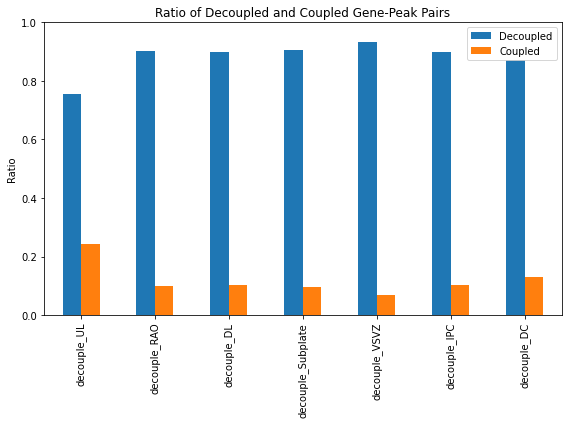

In [68]:
from gene_peaks import plot_ratio

plot_ratio(score_df2, ["decouple_UL", "decouple_RAO", "decouple_DL", "decouple_Subplate", "decouple_VSVZ", "decouple_IPC", "decouple_DC"], name="mouse_mouse_celltype_ratio")

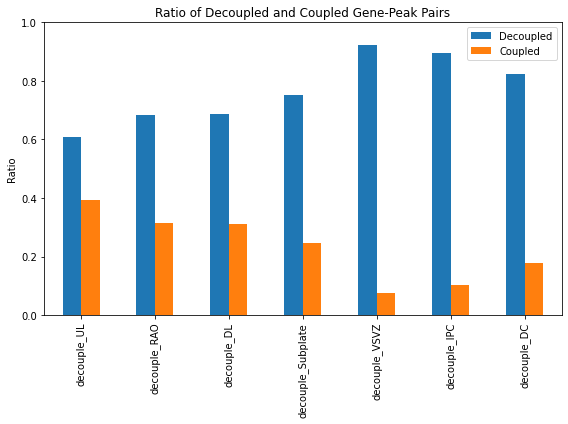

In [81]:
plot_ratio(df_combined, ["decouple_UL", "decouple_RAO", "decouple_DL", "decouple_Subplate", "decouple_VSVZ", "decouple_IPC", "decouple_DC"], name="mouse_mouse_celltype500_ratio")

In [84]:
genename = "WNT3"
genename = genename.upper()
get_gene_local_atac(genename, litemodel, rna_data, atac_data, norm_X=atac_data.layers["norm"])
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= rna_data,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", save="hair_gene_peak/all/"+genename+".png", gquant=0.95)
# smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= irsrna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.95)

latent_time_8
0    3.816491
1    3.690448
2    3.874744
3    3.790994
4    3.634961
5    3.898110
6    3.529666
7    3.926936
Name: temp_gene, dtype: float32
latent_time_8
0    0.000029
1    0.000026
2    0.000023
3    0.000028
4    0.000023
5    0.000019
6    0.000016
7    0.000015
Name: local_peaks, dtype: float32


latent_time_8
0    3.816491
1    4.046216
2    3.603166
3    3.787740
4    2.672567
5    0.000000
6    3.529666
7    3.926936
Name: temp_gene, dtype: float32
latent_time_8
0    0.000025
1    0.000021
2    0.000015
3    0.000015
4    0.000016
5    0.000017
6    0.000016
7    0.000015
Name: local_peaks, dtype: float32
latent_time_8
0    3.816491
1    4.046216
2    3.603166
3    3.787740
4    2.672567
5    0.000000
6    3.529666
7    3.926936
Name: temp_gene, dtype: float32
latent_time_8
0    0.000025
1    0.000021
2    0.000015
3    0.000015
4    0.000016
5    0.000017
6    0.000016
7    0.000015
Name: local_peaks, dtype: float32
latent_time_8
0    3.791097
1    3.769834
2    3.691059
3    3.944159
4    3.807837
5    2.974885
6    0.000000
7    3.926936
Name: temp_gene, dtype: float32
latent_time_8
0    0.000029
1    0.000025
2    0.000023
3    0.000031
4    0.000027
5    0.000021
6    0.000021
7    0.000021
Name: local_peaks, dtype: float32
latent_time_8
0    3.791097
1    3.769834
2   

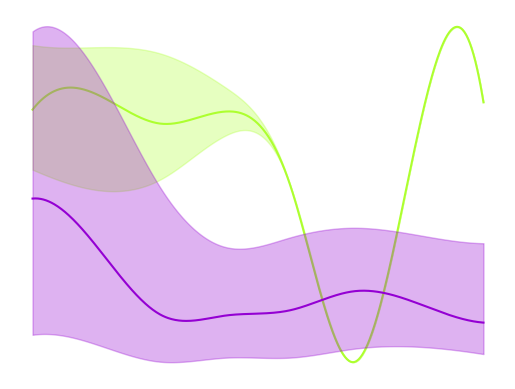

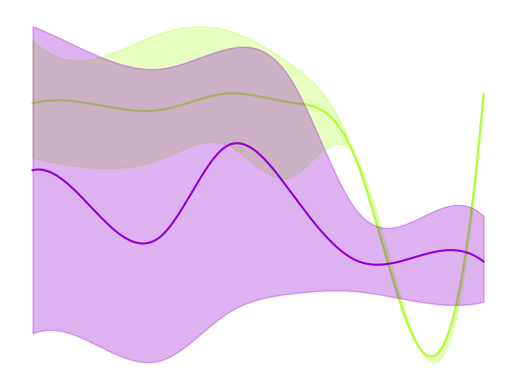

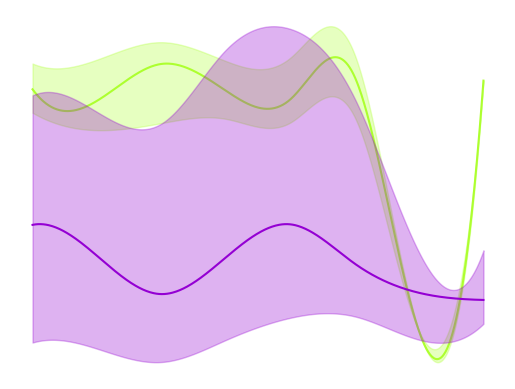

In [71]:
genename = "WNT3"
get_gene_local_atac(genename, litemodel,irsrna, irsatac, norm_X=irsatac.layers["norm"])
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= irsrna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.95, pquant=0.8)
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= irsrna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.8, pquant=0.8, save="hair_gene_peak/IRS/"+genename+".png")
get_gene_local_atac(genename, litemodel,cortexrna, cortexatac, norm_X=cortexatac.layers["norm"])
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= cortexrna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.8, pquant=0.8, save="hair_gene_peak/cortex/"+genename+".png")
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= cortexrna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.95, pquant=0.8)

get_gene_local_atac(genename, litemodel,medullarna, medullaatac, norm_X=medullaatac.layers["norm"])

smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= medullarna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.8, pquant=0.8, save="hair_gene_peak/medulla/"+genename+".png")
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= medullarna,linewidth = 2, points=500, gcolor="greenyellow", pcolor="darkviolet", gquant=0.8, pquant=0.8)

In [52]:
get_gene_local_atac(genename, litemodel,irsrna, irsatac, norm_X=irsatac.layers["norm"])
irsrna.obs["local_peaks"]

0_paired       0.000012
1_paired       0.000012
2_paired       0.000029
3_paired       0.000009
4_paired       0.000014
                 ...   
5433_paired    0.000039
5434_paired    0.000026
5435_paired    0.000029
5436_paired    0.000035
5437_paired    0.000023
Name: local_peaks, Length: 4626, dtype: float32

In [558]:
genename = "KLF6"
genename = genename.upper()
get_gene_local_atac(genename, litemodel, irsrna, irsatac, norm_X=irsatac.layers["norm"])
smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= irsrna,linewidth = 2, points=500, pcolor="black", gcolor="goldenrod"), 

['KLF6']

In [521]:
genes = ["NTN1"]
for genename in genes:
    # smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=irsrna, atac_data=irsatac, norm_X = irsatac.layers["norm"],
    # linewidth=1, gcolor="greenyellow", pcolor="darkviolet", save="hair_gene_peak/IRS/marker/"+genename+".jpg")
    get_gene_local_atac(genename, litemodel, irsrna, irsatac, norm_X=irsatac.layers["norm"])
    smooth_gene_peaks_plot_interv(genename,time="latent_time_8",rna_data= irsrna,linewidth = 2, points=500,gcolor="greenyellow", pcolor="darkviolet", save="hair_gene_peak/IRS/marker/"+genename+".jpg"),

In [682]:
gene_level_casual_nonzero("LEF1","latent_time_8", litemodel,cortexrna, cortexatac, norm_X=cortexatac.layers["norm"],width=0.001, thresh=1e-5)

(0.0006065622661518694,
 0.038648681115910646,
 0.039255243382062516,
 -0.0006165622661518694)

In [427]:
score_df.to_csv("hair_gene_peak/score_full_updated.csv")

In [256]:
se_gene = pd.read_csv("hair_gene_peak/score_full.csv")
genelist = se_gene[se_gene.super_enhancer==True].gene.to_list()
path = "hair_gene_peak/super_enhancer/IRS/"
for genename in genelist:
    warnings.filterwarnings('ignore')
    smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=irsrna, atac_data=irsatac, norm_X = irsatac.layers["norm"],
        linewidth=1, ticks=False, title=False, gcolor="greenyellow", pcolor="darkviolet", save=path+genename+".jpg")

In [257]:
se_gene = pd.read_csv("hair_gene_peak/score_full.csv")
genelist = se_gene[se_gene.super_enhancer==True].gene.to_list()
path = "hair_gene_peak/super_enhancer/medulla/"
for genename in genelist:
    warnings.filterwarnings('ignore')
    smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=medullarna, atac_data=medullaatac, norm_X = medullaatac.layers["norm"],
        linewidth=1, ticks=False, title=False, gcolor="greenyellow", pcolor="darkviolet", save=path+genename+".jpg")

In [258]:
se_gene = pd.read_csv("hair_gene_peak/score_full.csv")
genelist = se_gene[se_gene.super_enhancer==True].gene.to_list()
path = "hair_gene_peak/super_enhancer/cortex/"
for genename in genelist:
    warnings.filterwarnings('ignore')
    smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=cortexrna, atac_data=cortexatac, norm_X = cortexatac.layers["norm"],
        linewidth=1, ticks=False, title=False, gcolor="greenyellow", pcolor="darkviolet", save=path+genename+".jpg")

In [255]:
se_gene = pd.read_csv("hair_gene_peak/score_full.csv")
genelist = se_gene[se_gene.super_enhancer==True].gene.to_list()
path = "hair_gene_peak/super_enhancer/all/"
for genename in genelist:
    warnings.filterwarnings('ignore')
    smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=rna_data, atac_data=atac_data, norm_X = atac_data.layers["norm"],
        linewidth=1, ticks=False, title=False, gcolor="greenyellow", pcolor="darkviolet", save=path+genename+".jpg")

In [38]:
score_df = score_df2[score_df2.super_enhancer==True]
score_df["max_decouple"] =  score_df[['decouple_score', 'decouple_medulla', 'decouple_cortex', "decouple_irs"]].max(axis=1)
score_df["max_couple"] =  score_df[['couple_score', 'couple_medulla', 'couple_cortex', "couple_irs"]].max(axis=1)
score_df_melt = pd.melt(score_df, id_vars=["gene"], 
value_vars=["decouple_score", "decouple_cortex","decouple_irs", "decouple_medulla", "max_decouple","couple_score","couple_cortex","couple_irs", "couple_medulla","max_couple"])
score_df_melt

,gene,variable,value
0,ABL2,decouple_score,-0.005697
1,ACVR1B,decouple_score,0.001309
2,ADARB1,decouple_score,-0.003166
3,AFF3,decouple_score,0.003459
4,AGPAT3,decouple_score,-0.003275
...,...,...,...
1165,TRP53BP2,max_couple,0.009332
1166,VGLL4,max_couple,0.008711
1167,ZFAND5,max_couple,0.017087
1168,ZFP750,max_couple,0.000427


In [113]:
score_df2 = pd.DataFrame({"gene":score_df.gene, "couple_score": couple_scores, "decouple_score": decouple_scores, "decouple_irs":decouple_score_irs, 
                        "couple_irs":couple_score_irs, "decouple_cortex":decouple_score_cortex, "couple_cortex":couple_score_cortex, 
                        "decouple_medulla":decouple_score_medulla, "couple_medulla":couple_score_medulla})
score_df2                        

,gene,couple_score,decouple_score,decouple_irs,couple_irs,decouple_cortex,couple_cortex,decouple_medulla,couple_medulla
0,ENOX1,-0.005306,0.005296,-0.006117,0.006107,0.005971,-0.005981,-0.001292,0.001282
1,DCTN1,-0.002297,0.002287,-0.001700,0.001690,-0.000512,0.000502,0.001317,-0.001327
2,MAGI1,0.016544,-0.016554,-0.001090,0.001080,-0.007149,0.007139,0.003968,-0.003978
3,FBRSL1,-0.000407,0.000397,0.006046,-0.006056,0.001441,-0.001451,0.009925,-0.009935
4,KIF15,-0.001201,0.001191,-0.000779,0.000769,0.001461,-0.001471,0.002616,-0.002626
...,...,...,...,...,...,...,...,...,...
112,TRP53BP2,-0.004417,0.004407,0.006183,-0.006193,0.004001,-0.004011,-0.003781,0.003771
113,VGLL4,-0.000667,0.000657,0.006380,-0.006390,0.004686,-0.004696,0.004370,-0.004380
114,ZFAND5,0.002957,-0.002967,-0.001430,0.001420,0.001426,-0.001436,0.001910,-0.001920
115,ZFP750,-0.014534,0.014524,0.016083,-0.016093,0.007929,-0.007939,0.001610,-0.001620


In [114]:
score_df2["max_decouple"] =  score_df2[['decouple_score', 'decouple_medulla', 'decouple_cortex', "decouple_irs"]].max(axis=1)
score_df2["max_couple"] =  score_df2[['couple_score', 'couple_medulla', 'couple_cortex', "couple_irs"]].max(axis=1)
score_df_melt2 = pd.melt(score_df2, id_vars=["gene"], 
value_vars=["decouple_score", "decouple_cortex","decouple_irs", "decouple_medulla", "max_decouple","couple_score","couple_cortex","couple_irs", "couple_medulla","max_couple"])
score_df_melt2

,gene,variable,value
0,ENOX1,decouple_score,0.005296
1,DCTN1,decouple_score,0.002287
2,MAGI1,decouple_score,-0.016554
3,FBRSL1,decouple_score,0.000397
4,KIF15,decouple_score,0.001191
...,...,...,...
2745,TRP53BP2,max_couple,0.003771
2746,VGLL4,max_couple,-0.000667
2747,ZFAND5,max_couple,0.002957
2748,ZFP750,max_couple,-0.001620


In [116]:
score_df2.to_csv("hair_gene_peak/score_full_new.csv")

In [430]:
score_en = score_df[score_df.super_enhancer==True]
score_en_melt = pd.melt(score_en, id_vars=["gene"], 
value_vars=["decouple_score", "decouple_cortex","decouple_irs", "decouple_medulla", "max_decouple","couple_score","couple_cortex","couple_irs", "couple_medulla","max_couple"])
score_en_melt


,gene,variable,value
0,ABL2,decouple_score,0.015079
1,ACVR1B,decouple_score,-0.004606
2,ADARB1,decouple_score,-0.002629
3,AFF3,decouple_score,-0.000649
4,AGPAT3,decouple_score,0.000335
...,...,...,...
1165,TRP53BP2,max_couple,0.001860
1166,VGLL4,max_couple,0.008362
1167,ZFAND5,max_couple,0.000290
1168,ZFP750,max_couple,-0.000332


In [71]:
irs_df = score_df[(score_df['decouple score']<0) & (score_df['decouple_irs']>0)].sort_values("decouple_irs", ascending=False)

In [111]:
irs_df.to_csv("hair_gene_peak/IRS_decouple.csv")

In [101]:
import warnings
path = "hair_gene_peak/IRS/marker/"
for genename in ["MT2", "CTSC", "KRT71", "KRT28", "TCHH", "BAMBI"]:
    warnings.filterwarnings('ignore')
    save = path+genename+".jpg"
    try:
        get_gene_local_atac(genename, litemodel, irsrna, irsatac, norm_X=irsatac.layers["norm"])

        smooth_gene_peaks_plot_interv(genename, time="latent_time_8", rna_data=irsrna, linewidth=1, ticks=True, title=True, gcolor="greenyellow", pcolor="darkviolet",save=save)
    except:
        print(genename)   

In [110]:
import warnings
path = "hair_gene_peak/IRS/marker/TF/"
for genename in ["CUX1", "GRHL1", "GATA3", "MAF"]:
    warnings.filterwarnings('ignore')
    save = path+genename+".jpg"
    try:
        get_gene_local_atac(genename, litemodel, irsrna, irsatac, norm_X=irsatac.layers["norm"])

        smooth_gene_peaks_plot_interv(genename, time="latent_time_8", rna_data=irsrna, linewidth=1, ticks=True, title=True, gcolor="greenyellow", pcolor="darkviolet",save=save)
    except:
        print(genename)   

In [309]:
[e for e in rna_data.var.index if "KITL" in e]

['KITL']

In [340]:
path="hair_gene_peak/super_enhancer/decouple/"
genename = "LEF1"
smooth_gene_peaks_plot_interv_2(genename, time="latent_time_8", litemodel=litemodel, rna_data=rna_data, atac_data=atac_data, norm_X = atac_data.layers["norm"],
linewidth=1, ticks=True, title=True, gcolor="greenyellow", pcolor="darkviolet", save=path+genename+".jpg")

In [723]:
genelist = ["PTCH2"]
decouple_score_cortex=[]
couple_score_cortex = []
decouple_score_irs = []
couple_score_irs = []
decouple_score_medulla = []
couple_score_medulla = []
decouple_scores = []
couple_scores = []
time="latent_time"
width=1e-3
for i in tqdm(range(len(genelist))):
    genename = genelist[i]
    try: 

        decouple_score_c, _, _, couple_score_c = gene_level_casual_nonzero(genename,time, litemodel,cortexrna,cortexatac, norm_X=cortexatac.layers["norm"],width=width, thresh=1e-5)
        decouple_score_cortex.append(decouple_score_c)
        couple_score_cortex.append(couple_score_c)

        decouple_score_i, _, _, couple_score_i = gene_level_casual_nonzero(genename,time, litemodel,irsrna,irsatac, norm_X=irsatac.layers["norm"],width=width, thresh=1e-5)
        decouple_score_irs.append(decouple_score_i)
        couple_score_irs.append(couple_score_i)


        decouple_score_m, _, _, couple_score_m = gene_level_casual_nonzero(genename,time, litemodel,medullarna,medullaatac, norm_X=medullaatac.layers["norm"],width=width, thresh=1e-5)
        decouple_score_medulla.append(decouple_score_m)
        couple_score_medulla.append(couple_score_m)



        decouple_score, _, _, couple_score = gene_level_casual_nonzero(genename,time, litemodel,rna_data,atac_data, norm_X=atac_data.layers["norm"],width=width, thresh=1e-5)
        decouple_scores.append(decouple_score)
        couple_scores.append(couple_score)

    except:
        print(genename)
        failed.append(genename)

100%|██████████| 1/1 [03:31<00:00, 211.62s/it]


In [724]:
score_add = pd.DataFrame({"gene":genelist, "decouple_score": decouple_scores, "couple_score":couple_scores, 
"decouple_cortex":decouple_score_cortex, "couple_cortex":couple_score_cortex, "decouple_irs":decouple_score_irs, 
"couple_irs":couple_score_irs, "decouple_medulla":decouple_score_medulla, "couple_medula":couple_score_medulla})
score_add

,gene,decouple_score,couple_score,decouple_cortex,couple_cortex,decouple_irs,couple_irs,decouple_medulla,couple_medula
0,PTCH2,-0.002104,0.002094,-0.000611,0.000601,0.000068,-0.000078,-0.000373,0.000363


In [603]:
score_add["decouple_score"] = -score_add["decouple_score"]
score_add["couple_score"] = -score_add["couple_score"]
score_add["decouple_cortex"] = -score_add["decouple_cortex"]
score_add["couple_cortex"] = -score_add["couple_cortex"]
score_add["decouple_irs"] = -score_add["decouple_irs"]
score_add["couple_irs"] = -score_add["couple_irs"]
score_add["decouple_medulla"] = -score_add["decouple_medulla"]
score_add["couple_medula"] = -score_add["couple_medula"]
score_add


,gene,decouple_score,couple_score,decouple_cortex,couple_cortex,decouple_irs,couple_irs,decouple_medulla,couple_medula
0,CTSC,0.004216,-0.004206,0.000972,-0.000962,0.010803,-0.010793,0.006979,-0.006969


In [707]:
score_df = score_df.append(score_add)

In [365]:
gene_level_casual_nonzero("HTRA1","latent_time", litemodel,rna_data,atac_data, norm_X=atac_data.layers["norm"],width=0.1, thresh=1e-5)

(0.0006315830466405298,
 0.07283016416685328,
 0.07346174721349381,
 -0.0006415830466405298)

In [118]:
genename = "PTCH2"
decouple_score, _, _, couple_score = gene_level_casual_nonzero(genename,time, litemodel,rna_data,atac_data, norm_X=atac_data.layers["norm"],width=0.1, thresh=1e-5)
print(decouple_score, couple_score)
decouple_score_c, _, _, couple_score_c = gene_level_casual_nonzero(genename,time, litemodel,cortexrna,cortexatac, norm_X=cortexatac.layers["norm"],width=0.1, thresh=1e-5)
print(decouple_score_c, couple_score_c)
decouple_score_i, _, _, couple_score_i = gene_level_casual_nonzero(genename,time, litemodel,irsrna,irsatac, norm_X=irsatac.layers["norm"],width=0.1, thresh=1e-5)
print(decouple_score_i, couple_score_i)
decouple_score_m, _, _, couple_score_m = gene_level_casual_nonzero(genename,time, litemodel,medullarna,medullaatac, norm_X=medullaatac.layers["norm"],width=0.1, thresh=1e-5)
print(decouple_score_m, couple_score_m)

0.003486840857034379 -0.003496840857034379
-0.004016099013466265 0.004006099013466265
-0.007003364734533557 0.006993364734533557
-0.00354126465085107 0.0035312646508510698
